# TextBlob Polarity Algorithm — From-Scratch Implementation
## CMU-MOSI Transcript Sentiment Analyser with Word-Level Colour Highlighting

> **Goal:** Re-implement the complete TextBlob polarity/subjectivity scoring
> algorithm from first principles — XML lexicon loading, whitespace-preserving
> tokenisation, modifier detection (negators + intensifiers), per-token adjusted
> scoring, and mean-aggregation — then apply it to **five real CMU-MOSI film-review
> transcripts**, displaying the entire text with every sentiment-bearing word
> colour-highlighted by its contribution.

**Notebook layout:**
- Every *markdown cell* states the **mathematical foundation** (Axioms, Definitions,
  Lemmas, Theorems) that the immediately following *code cell* implements precisely.
- Colour key: 🟢 greens = positive polarity · 🔴 reds = negative polarity ·
  opacity ∝ subjectivity strength · hover any highlighted word for exact scores.


---
## § 1  Sentiment Lexicon — Formal Foundations

### Axiom 1  (Pattern Lexicon)
Let $\mathcal{W}$ be the set of lowercase English word forms and let
$\mathcal{L} \subset \mathcal{W}$ be a **finite sentiment lexicon**.
Each entry maps a word to a non-empty multi-set of *sense tuples*:

$$\mathcal{L}(w) = \{\,(p_k,\; s_k,\; \iota_k)\}_{k=1}^{K_w}, \quad p_k\in[-1,+1],\; s_k\in[0,1],\; \iota_k\in\mathbb{R}_{>0}$$

where $p_k$ is **polarity**, $s_k$ **subjectivity**, and $\iota_k$ **intensity**.
The TextBlob/Pattern lexicon (`en-sentiment.xml`) contains **2,918 sense entries**
covering **1,528 distinct word forms**.

### Definition 1.1  (Aggregate Base Scores)
For $w \in \mathcal{L}$, the **aggregate base polarity and subjectivity** are
the arithmetic means over all senses:

$$\bar{p}(w) = \frac{1}{K_w}\sum_{k=1}^{K_w}p_k, \qquad \bar{s}(w) = \frac{1}{K_w}\sum_{k=1}^{K_w}s_k$$

For $w\notin\mathcal{L}$, define $\bar{p}(w)=\bar{s}(w)=0$.

### Axiom 2  (Modifier Vocabulary)
Define two **disjoint** modifier sets:

$$\mathcal{N}=\{\textit{not, no, never, neither, nor, without, hardly, barely, nothing, nowhere}\}$$

$$\mathcal{I}: \mathcal{M}\to\mathbb{R}_{>0}, \quad \text{e.g.}\; \mathcal{I}(\textit{very})=1.5,\;\mathcal{I}(\textit{extremely})=2.0,\;\mathcal{I}(\textit{somewhat})=0.5$$

### Lemma 1.1  (Lexicon Completeness)
The function $\bar{p}:\mathcal{W}\to[-1,+1]$ is **total**: it returns a
well-defined real value for every lowercase word (zero for out-of-vocabulary words).

*Proof.* By Axiom 1, $K_w\ge 1$ for $w\in\mathcal{L}$, so the sum is finite.
For $w\notin\mathcal{L}$ the value is defined to be $0$.  $\square$


In [1]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 1 — Dependencies · Lexicon loading · Modifier sets
#  Implements: Axiom 1, Definition 1.1, Axiom 2, Lemma 1.1
# ═══════════════════════════════════════════════════════════════════════
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','-q','textblob'],
               capture_output=True)

import xml.etree.ElementTree as ET
import re, os, math, warnings
import numpy as np
from collections import defaultdict
warnings.filterwarnings('ignore')

# ── Locate bundled XML (ships with every textblob install) ──────────
import textblob as _tb
XML_PATH = os.path.join(os.path.dirname(_tb.__file__), 'en', 'en-sentiment.xml')
assert os.path.exists(XML_PATH), f'Lexicon not found: {XML_PATH}'

# ── Build LEXICON: word → list[{p, s, intens}]  (Axiom 1) ──────────
LEXICON = defaultdict(list)
for _e in ET.parse(XML_PATH).getroot():
    _f = _e.attrib.get('form','').strip().lower()
    if not _f: continue
    LEXICON[_f].append({
        'p':     float(_e.attrib.get('polarity',     '0')),
        's':     float(_e.attrib.get('subjectivity', '0')),
        'intens':float(_e.attrib.get('intensity',    '1')),
    })
LEXICON = dict(LEXICON)
print(f'Lexicon: {len(LEXICON):,} word forms, '
      f'{sum(len(v) for v in LEXICON.values()):,} sense entries')
print(f'Source : {XML_PATH}')

# ── Modifier sets (Axiom 2) ─────────────────────────────────────────
NEGATORS = frozenset({
    'not','no','never','neither','nor',
    'without','hardly','barely','nothing','nowhere',
})
INTENSIFIERS = {
    'very':1.5, 'extremely':2.0, 'really':1.5, 'incredibly':2.0,
    'absolutely':2.0, 'totally':1.5, 'utterly':2.0,
    'quite':1.3, 'rather':1.2, 'somewhat':0.5, 'fairly':0.8, 'slightly':0.5,
}
print(f'Negators     : {len(NEGATORS)} words')
print(f'Intensifiers : {len(INTENSIFIERS)} words')

# ── Definition 1.1: aggregate base scores ──────────────────────────
def base_scores(word_lower):
    """Return (p_bar, s_bar) for word; (0,0) if OOV."""
    if word_lower not in LEXICON:
        return 0.0, 0.0
    senses = LEXICON[word_lower]
    return (sum(e['p'] for e in senses)/len(senses),
            sum(e['s'] for e in senses)/len(senses))

# ── Spot-check ──────────────────────────────────────────────────────
demo_words = ['loved','great','terrible','boring','nice','awful','good','bad','flat','fun']
print(f"\n{'Word':12s} {'Senses':>7s} {'p̄':>8s} {'s̄':>8s}")
print('─'*40)
for w in demo_words:
    pb, sb = base_scores(w)
    n = len(LEXICON.get(w,[]))
    print(f'{w:12s} {n:>7d} {pb:>+8.3f} {sb:>8.3f}')


Lexicon: 1,528 word forms, 2,918 sense entries
Source : /usr/local/lib/python3.12/dist-packages/textblob/en/en-sentiment.xml
Negators     : 10 words
Intensifiers : 12 words

Word          Senses       p̄       s̄
────────────────────────────────────────
loved              1   +0.700    0.800
great              4   +0.800    0.750
terrible           4   -1.000    1.000
boring             1   -1.000    1.000
nice               2   +0.600    1.000
awful              1   -1.000    1.000
good               2   +0.700    0.600
bad                3   -0.700    0.667
flat               4   -0.025    0.125
fun                1   +0.300    0.200


---
## § 2  Whitespace-Preserving Tokenisation

### Definition 2.1  (Tokeniser)
The **tokeniser** $\tau:\Sigma^*\to\mathcal{W}^*$ maps a raw string $s$ to an
ordered sequence of tokens, each consisting solely of letters and apostrophes:

$$\tau(s)=\bigl[m \mid m\text{ is a maximal match of regex }\texttt{[a-zA-Z']+}\text{ in }s\bigr]$$

Each token $t_i$ carries the triple $(\mathit{raw}_i, \mathit{lower}_i, \mathit{start}_i, \mathit{end}_i)$, where $\mathit{start}_i/\mathit{end}_i$
are character offsets in the **original** string $s$.

### Lemma 2.1  (Determinism)
$\tau$ is **deterministic**: identical inputs always produce identical token
sequences.  
*Proof.* Regular-expression matching on a fixed string is a deterministic finite
automaton. $\square$

### Lemma 2.2  (Offset Fidelity)
For every token $t_i$, $s[t_i.\mathit{start}\,:\,t_i.\mathit{end}]=t_i.\mathit{raw}$.
This guarantees **lossless reconstruction** of $s$ with arbitrary markup inserted
between tokens. $\square$


In [2]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 2 — Tokeniser  (Definition 2.1, Lemmas 2.1–2.2)
# ═══════════════════════════════════════════════════════════════════════

def tokenize(text):
    """
    τ(s) — returns list of dicts {raw, lower, start, end}.
    Character offsets allow perfect whitespace-preserving
    reconstruction for HTML display (Lemma 2.2).
    """
    return [
        {'raw':m.group(), 'lower':m.group().lower(),
         'start':m.start(), 'end':m.end()}
        for m in re.finditer(r"[a-zA-Z']+", text)
    ]

# ── Demonstration ───────────────────────────────────────────────────
_demo = "It wasn't really GREAT — absolutely awful."
_toks = tokenize(_demo)
print(f'Input: {_demo!r}\n')
print(f"{'i':>3}  {'raw':15} {'lower':15} {'start':>6} {'end':>4}")
print('─'*50)
for i,t in enumerate(_toks):
    print(f"{i:>3}  {t['raw']:15} {t['lower']:15} {t['start']:>6} {t['end']:>4}")

# Verify Lemma 2.2
for t in _toks:
    assert _demo[t['start']:t['end']] == t['raw']
print('\n✓  Offset fidelity verified (Lemma 2.2)')


Input: "It wasn't really GREAT — absolutely awful."

  i  raw             lower            start  end
──────────────────────────────────────────────────
  0  It              it                   0    2
  1  wasn't          wasn't               3    9
  2  really          really              10   16
  3  GREAT           great               17   22
  4  absolutely      absolutely          25   35
  5  awful           awful               36   41

✓  Offset fidelity verified (Lemma 2.2)


---
## § 3  Per-Token Adjusted Scoring

### Definition 3.1  (Context Window)
For token at position $i$ in sequence $(w_0,\ldots,w_{n-1})$,
the **left context window** of radius $k=3$ is:

$$\mathcal{C}_3(i)=\{w_{\max(0,i-3)}^{\prime},\ldots,w_{i-1}^{\prime}\}$$

where $w_j^{\prime}$ denotes the lowercase form of $w_j$.

### Definition 3.2  (Negation Indicator)
$$\delta(i) = \mathbf{1}\bigl[\exists\,c\in\mathcal{C}_3(i):c\in\mathcal{N}\bigr]$$

### Definition 3.3  (Intensifier Multiplier)
$$\mu(i) = \begin{cases}
  \max_{c\in\mathcal{C}_3(i)\cap\mathcal{M}}\mathcal{I}(c)  & \text{if }\mathcal{C}_3(i)\cap\mathcal{M}\ne\emptyset\\
  1.0 & \text{otherwise}
\end{cases}$$

### Theorem 3.1  (Adjusted Token Score)
The **adjusted polarity** and **adjusted subjectivity** for token $w_i$ are:

$$\boxed{\tilde{p}(w_i) = \mu(i)\cdot(-1)^{\delta(i)}\cdot\bar{p}(w_i^{\prime})}$$

$$\tilde{s}(w_i) = \bar{s}(w_i^{\prime})$$

*Rationale.* Intensifiers scale opinion magnitude; negators reverse its sign.
Subjectivity is not sign-inverted because negating a subjective claim does not
make it objective. $\square$

### Lemma 3.1  (Boundedness)
$|\tilde{p}(w_i)|\le 2$ for any $\mu\le 2$ and $\bar{p}\in[-1,+1]$.
$\tilde{s}(w_i)\in[0,1]$ unchanged.  $\square$


In [3]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 3 — Per-token scorer  (Definitions 3.1–3.3, Theorem 3.1)
# ═══════════════════════════════════════════════════════════════════════

def score_token(word_lower, context_lowers):
    """
    Implements Theorem 3.1.
    Returns dict: {base_p, base_s, negated, intens_word,
                   intens_mu, adj_p, adj_s, in_lex, context}
    """
    out = {
        'base_p':0.0, 'base_s':0.0,
        'negated':False, 'intens_word':None, 'intens_mu':1.0,
        'adj_p':0.0, 'adj_s':0.0,
        'in_lex':False, 'context':list(context_lowers),
    }
    bp, bs = base_scores(word_lower)          # Definition 1.1
    out['base_p'], out['base_s'] = bp, bs
    if word_lower not in LEXICON:
        return out
    out['in_lex'] = True

    # Definition 3.2 — negation
    for c in context_lowers:
        if c in NEGATORS:
            out['negated'] = True
            break

    # Definition 3.3 — intensifier (highest μ in window)
    best_mu, best_w = 1.0, None
    for c in context_lowers:
        if c in INTENSIFIERS and INTENSIFIERS[c] > best_mu:
            best_mu, best_w = INTENSIFIERS[c], c
    out['intens_mu'], out['intens_word'] = best_mu, best_w

    # Theorem 3.1 — adjusted scores
    sign         = -1.0 if out['negated'] else 1.0
    out['adj_p'] = best_mu * sign * bp
    out['adj_s'] = bs
    return out

# ── Demonstration table ─────────────────────────────────────────────
_cases = [
    ('loved',    ['i','really']),
    ('great',    ['was']),
    ('terrible', ['was']),
    ('boring',   ['not','at','all']),
    ('good',     ['not']),
    ('nice',     ['very']),
    ('awful',    ['totally']),
    ('fun',      ['quite']),
    ('flat',     ['just']),
    ('fantastic',['absolutely']),
]
print(f"{'Word':12}  {'Context':28}  {'base_p':>7} {'μ':>5} {'neg':>5}  "
      f"{'adj_p':>7} {'adj_s':>7}")
print('─'*85)
for word, ctx in _cases:
    r = score_token(word, ctx)
    print(f"{word:12}  {str(ctx):28}  {r['base_p']:>+7.3f} "
          f"{r['intens_mu']:>5.1f} {str(r['negated']):>5}  "
          f"{r['adj_p']:>+7.3f} {r['adj_s']:>7.3f}")


Word          Context                        base_p     μ   neg    adj_p   adj_s
─────────────────────────────────────────────────────────────────────────────────────
loved         ['i', 'really']                +0.700   1.5 False   +1.050   0.800
great         ['was']                        +0.800   1.0 False   +0.800   0.750
terrible      ['was']                        -1.000   1.0 False   -1.000   1.000
boring        ['not', 'at', 'all']           -1.000   1.0  True   +1.000   1.000
good          ['not']                        +0.700   1.0  True   -0.700   0.600
nice          ['very']                       +0.600   1.5 False   +0.900   1.000
awful         ['totally']                    -1.000   1.5 False   -1.500   1.000
fun           ['quite']                      +0.300   1.3 False   +0.390   0.200
flat          ['just']                       -0.025   1.0 False   -0.025   0.125
fantastic     ['absolutely']                 +0.400   2.0 False   +0.800   0.900


---
## § 4  Sentence-Level Aggregation & Sentiment Label

### Definition 4.1  (Scored Index Set)
$$\mathcal{S}=\{\,i\in\{0,\ldots,n{-}1\}:w_i^{\prime}\in\mathcal{L}\text{ and }\bar{p}(w_i^{\prime})\ne 0\,\}$$

Only words that are **in the lexicon** and carry **non-zero base polarity**
contribute to the sentence score.

### Theorem 4.1  (Sentence Polarity)
$$\boxed{P(s)=\begin{cases}
  \dfrac{1}{|\mathcal{S}|}\displaystyle\sum_{i\in\mathcal{S}}\tilde{p}(w_i)  & |\mathcal{S}|>0\\[8pt]
  0 & |\mathcal{S}|=0
\end{cases}}$$

### Theorem 4.2  (Sentence Subjectivity)
$$\boxed{Q(s)=\begin{cases}
  \dfrac{1}{|\mathcal{S}|}\displaystyle\sum_{i\in\mathcal{S}}\tilde{s}(w_i)  & |\mathcal{S}|>0\\[8pt]
  0 & |\mathcal{S}|=0
\end{cases}}$$

### Corollary 4.1  (Range Bounds)
$P(s)\in[-2,+2]$ (from Lemma 3.1) and $Q(s)\in[0,1]$ (mean of values in $[0,1]$). $\square$

### Definition 4.2  (7-Class Sentiment Label)

| Range of $P(s)$ | Label |
|:---:|---|
| $P > 1.5$ | Strongly Positive |
| $0.5 < P \le 1.5$ | Positive |
| $0.05 < P \le 0.5$ | Slightly Positive |
| $-0.05 \le P \le 0.05$ | Neutral |
| $-0.5 \le P < -0.05$ | Slightly Negative |
| $-1.5 \le P < -0.5$ | Negative |
| $P < -1.5$ | Strongly Negative |

### Theorem 4.3  (Algorithm Completeness)
For any $s\in\Sigma^*$:
1. $\tau(s)$ terminates (finite string, deterministic regex).
2. Every token is either scored or assigned zero — no token is skipped.
3. $P(s)$ and $Q(s)$ are well-defined reals in $[-2,+2]$ and $[0,1]$. $\square$


In [4]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 4 — Full analysis pipeline  (Theorems 4.1–4.3, Corollary 4.1)
# ═══════════════════════════════════════════════════════════════════════

def sentiment_label(p):
    """Definition 4.2 — 7-class label."""
    if   p >  1.50: return 'Strongly Positive'
    elif p >  0.50: return 'Positive'
    elif p >  0.05: return 'Slightly Positive'
    elif p >= -0.05: return 'Neutral'
    elif p >= -0.50: return 'Slightly Negative'
    elif p >= -1.50: return 'Negative'
    else:            return 'Strongly Negative'


def analyse(text):
    """
    Complete pipeline: tokenise → score → aggregate.
    Returns dict with keys:
      tokens, scored_tokens, hits,
      polarity, subjectivity, label,
      n_tokens, n_scored, original_text
    """
    tokens = tokenize(text)
    n = len(tokens)
    scored = []
    for i, tok in enumerate(tokens):
        ctx  = [tokens[j]['lower'] for j in range(max(0, i-3), i)]
        info = score_token(tok['lower'], ctx)
        scored.append({**tok, **info, 'pos': i})

    # Definition 4.1 — scored index set
    hits = [t for t in scored if t['in_lex'] and t['base_p'] != 0]

    # Theorems 4.1 & 4.2
    if hits:
        pol = sum(t['adj_p'] for t in hits) / len(hits)
        sub = sum(t['adj_s'] for t in hits) / len(hits)
    else:
        pol = sub = 0.0

    return {
        'tokens': tokens, 'scored_tokens': scored, 'hits': hits,
        'polarity': pol, 'subjectivity': sub,
        'label': sentiment_label(pol),
        'n_tokens': n, 'n_scored': len(hits),
        'original_text': text,
    }


# ── Validate against official TextBlob ──────────────────────────────
from textblob import TextBlob

_samples = [
    'I really loved this movie — it was absolutely great!',
    'The ending was terrible and quite boring, not good at all.',
    'Nothing special. It was just OK, kind of flat.',
    'Totally fantastic and incredibly fun to watch.',
    'I would never say this was even slightly enjoyable.',
]
print(f"{'Text':52}  {'Our P':>7} {'TB P':>7}  {'Our Q':>7} {'TB Q':>7}")
print('─'*95)
for t in _samples:
    r  = analyse(t)
    tb = TextBlob(t).sentiment
    print(f"{t[:52]:52}  {r['polarity']:>+7.3f} {tb.polarity:>+7.3f}  "
          f"{r['subjectivity']:>7.3f} {tb.subjectivity:>7.3f}")


Text                                                    Our P    TB P    Our Q    TB Q
───────────────────────────────────────────────────────────────────────────────────────────────
I really loved this movie — it was absolutely great!   +1.325  +0.850    0.775   0.775
The ending was terrible and quite boring, not good a   -1.070  -0.783    0.867   0.867
Nothing special. It was just OK, kind of flat.         +0.179  +0.358    0.524   0.524
Totally fantastic and incredibly fun to watch.         +0.600  +0.350    0.550   0.550
I would never say this was even slightly enjoyable.    +0.500  +0.500    0.600   0.600


---
## § 5  Colour-Highlighting Engine

### Definition 5.1  (Polarity–Colour Map)
Define $\kappa:[-2,+2]\times[0,1]\to\text{CSS-rgba}$ by
$\kappa(\tilde{p},s_i)=\mathrm{rgba}(R,G,B,\alpha)$ where:

$$\alpha = 0.35 + 0.65\cdot s_i \qquad\text{(opacity encodes subjectivity)}$$

**Positive** $\tilde{p}\ge 0$: let $\xi=\min(\tilde{p},\,1)$
$$R=\lfloor 215-165\xi\rfloor,\quad G=\lfloor 240-70\xi\rfloor,\quad B=\lfloor 195-165\xi\rfloor$$
white $\xrightarrow{\xi\uparrow}$ light-green $\xrightarrow{\xi\to 1}$ dark-green

**Negative** $\tilde{p}<0$: let $\xi=\min(|\tilde{p}|,\,1)$
$$R=\lfloor 242-25\xi\rfloor,\quad G=\lfloor 200-168\xi\rfloor,\quad B=\lfloor 195-175\xi\rfloor$$
white $\xrightarrow{\xi\uparrow}$ light-red $\xrightarrow{\xi\to 1}$ dark-red

### Lemma 5.1  (Distinctiveness)
$\kappa$ separates any two words whose adjusted polarities differ by $\ge 0.05$
or whose subjectivities differ by $\ge 0.05$, producing a visually distinguishable
colour pair. $\square$

### Definition 5.2  (HTML Reconstruction)
Using the offsets from Lemma 2.2, the original string $s$ is reconstructed as

$$\hat{s}=s[0:t_1.\mathit{start}]\cdot\langle\text{span}\rangle_1\cdot
s[t_1.\mathit{end}:t_2.\mathit{start}]\cdots$$

so every whitespace character, punctuation mark, and line break in $s$ is
preserved exactly (no word is split or joined).


In [6]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 5 — Colour engine + HTML builder
#  Implements: Definition 5.1 (colour map), Definition 5.2 (reconstruction)
# ═══════════════════════════════════════════════════════════════════════

def polarity_to_rgba(p, s):
    """Definition 5.1 — maps (adj_p, subjectivity) → CSS rgba string."""
    p = max(-2.0, min(2.0, p))
    s = max(0.0,  min(1.0, s))
    alpha = 0.35 + 0.65 * s
    if p >= 0:
        xi = min(p, 1.0)
        R = int(215 - 165*xi)
        G = int(240 -  70*xi)
        B = int(195 - 165*xi)
    else:
        xi = min(abs(p), 1.0)
        R = int(242 -  25*xi)
        G = int(200 - 168*xi)
        B = int(195 - 175*xi)
    return f'rgba({R},{G},{B},{alpha:.2f})'


# ── Legend items ────────────────────────────────────────────────────
_LEGEND = [
    ('Strong Positive  (≥ +0.75)',  'rgba(50,170,30,0.92)'),
    ('Medium Positive  (≥ +0.30)',  'rgba(120,215,90,0.88)'),
    ('Light Positive   (≥ +0.01)',  'rgba(200,238,175,0.82)'),
    ('Light Negative   (≤ −0.01)',  'rgba(240,195,193,0.82)'),
    ('Medium Negative  (≤ −0.30)',  'rgba(225,110,75,0.88)'),
    ('Strong Negative  (≤ −0.75)',  'rgba(215,35,25,0.92)'),
    ('Subjectivity-only (p = 0)',    'rgba(195,195,255,0.60)'),
]
# Fix inline style collision
_LEGEND_HTML = ''.join(
    f'<span style="display:inline-block;background:{c};padding:2px 10px;'
    f'margin:2px 3px;border-radius:4px;font-size:11px;">{lbl}</span>'
    for lbl,c in _LEGEND
)


def build_html(result, title):
    """Definition 5.2 — reconstruct original text with coloured word spans."""
    orig   = result['original_text']
    stoks  = {t['pos']: t for t in result['scored_tokens']}
    tokens = result['tokens']

    parts, prev = [], 0
    for i, tok in enumerate(tokens):
        # preserve gap (spaces / punctuation) before this token
        parts.append(orig[prev:tok['start']])
        prev = tok['end']
        si = stoks[i]

        if si['in_lex'] and si['base_p'] != 0:
            bg  = polarity_to_rgba(si['adj_p'], si['adj_s'])
            neg = 'negated ' if si['negated'] else ''
            mu  = f"\u00d7{si['intens_mu']:.1f} " if si['intens_mu'] != 1.0 else ''
            ctx = ', '.join(si['context']) if si['context'] else 'none'
            tip = (f"adj_p={si['adj_p']:+.3f} "
                   f"(base={si['base_p']:+.3f}, {neg}{mu}s={si['adj_s']:.2f}, ctx=[{ctx}])")
            parts.append(
                f'<span style="background:{bg};padding:1px 4px;'
                f'border-radius:3px;font-weight:600;cursor:help;'
                f'border-bottom:1.5px solid rgba(0,0,0,0.15);"'
                f' title="{tip}">{tok["raw"]}</span>'
            )
        elif si['in_lex']:
            # In lexicon but p=0 → subjectivity-only
            bg = f"rgba(195,195,255,{0.25+0.45*si['adj_s']:.2f})"
            parts.append(
                f'<span style="background:{bg};padding:1px 4px;'
                f'border-radius:3px;font-style:italic;"'
                f' title="p=0 subjectivity word">{tok["raw"]}</span>'
            )
        else:
            parts.append(tok['raw'])

    parts.append(orig[prev:])
    body = ''.join(parts)

    p, q = result['polarity'], result['subjectivity']
    pc  = '#1a7a1a' if p >= 0 else '#b01010'
    bg_bar = 'rgba(40,160,60,0.80)' if p >= 0 else 'rgba(210,45,45,0.80)'
    bar_pct  = int((p + 2.0) / 4.0 * 100)   # map [-2,+2] → [0,100]%
    sub_pct  = int(q * 100)
    ml = 'margin-left:50%' if bar_pct > 50 else f'margin-left:{bar_pct}%'
    bw = abs(bar_pct - 50)
    subj_str = ('Very Subjective' if q > 0.70 else
                'Subjective'      if q > 0.50 else
                'Mixed'           if q > 0.30 else 'Objective')

    return (
        f'<div style="font-family:Arial,sans-serif;max-width:1020px;'
        f'margin:14px 0;padding:18px;border:1px solid #c8c8c8;'
        f'border-radius:10px;background:#fafafa;">'
        f'<h3 style="margin:0 0 12px;color:#222;">\U0001f4c4 {title}</h3>'

        # ── metric cards ──
        f'<div style="display:flex;gap:16px;flex-wrap:wrap;margin-bottom:14px;">'
        f'<div style="background:#fff;border:1px solid #ccc;border-radius:8px;'
        f'padding:10px 16px;min-width:160px;">'
        f'<div style="font-size:10px;color:#888;text-transform:uppercase;'
        f'letter-spacing:.5px;">Polarity  P(s)</div>'
        f'<div style="font-size:28px;font-weight:800;color:{pc};line-height:1.2;">'
        f'{p:+.4f}</div>'
        f'<div style="font-size:12px;color:#555;margin-top:2px;">'
        f'{result["label"]}</div></div>'

        f'<div style="background:#fff;border:1px solid #ccc;border-radius:8px;'
        f'padding:10px 16px;min-width:160px;">'
        f'<div style="font-size:10px;color:#888;text-transform:uppercase;'
        f'letter-spacing:.5px;">Subjectivity  Q(s)</div>'
        f'<div style="font-size:28px;font-weight:800;color:#444;line-height:1.2;">'
        f'{q:.4f}</div>'
        f'<div style="font-size:12px;color:#888;margin-top:2px;">{subj_str}</div></div>'

        f'<div style="background:#fff;border:1px solid #ccc;border-radius:8px;'
        f'padding:10px 16px;min-width:160px;">'
        f'<div style="font-size:10px;color:#888;text-transform:uppercase;'
        f'letter-spacing:.5px;">Scored tokens</div>'
        f'<div style="font-size:28px;font-weight:800;color:#444;line-height:1.2;">'
        f'{result["n_scored"]}'
        f'<span style="font-size:15px;font-weight:400;"> / {result["n_tokens"]}</span>'
        f'</div>'
        f'<div style="font-size:12px;color:#888;margin-top:2px;">'
        f'influencing score</div></div>'
        f'</div>'

        # ── polarity bar ──
        f'<div style="margin-bottom:8px;">'
        f'<div style="font-size:10px;color:#999;margin-bottom:3px;">'
        f'Polarity  [\u22122 \u2190 0 \u2192 +2]</div>'
        f'<div style="background:#e0e0e0;border-radius:5px;height:13px;'
        f'position:relative;">'
        f'<div style="position:absolute;left:50%;width:2px;height:13px;'
        f'background:#999;"></div>'
        f'<div style="background:{bg_bar};width:{bw}%;{ml};'
        f'height:13px;border-radius:4px;opacity:.75;"></div>'
        f'</div>'
        f'<div style="display:flex;justify-content:space-between;'
        f'font-size:10px;color:#bbb;margin-top:2px;">'
        f'<span>\u22122</span><span>0</span><span>+2</span></div></div>'

        # ── subjectivity bar ──
        f'<div style="margin-bottom:16px;">'
        f'<div style="font-size:10px;color:#999;margin-bottom:3px;">'
        f'Subjectivity  [0 = Objective \u2192 1 = Subjective]</div>'
        f'<div style="background:#e0e0e0;border-radius:5px;height:9px;">'
        f'<div style="background:rgba(85,85,195,.65);width:{sub_pct}%;'
        f'height:9px;border-radius:5px;"></div></div></div>'

        # ── highlighted text ──
        f'<div style="background:#fff;padding:14px 18px;'
        f'border:1px solid #e2e2e2;border-radius:8px;'
        f'line-height:2.3;font-size:15px;word-spacing:1px;">'
        f'{body}</div>'

        # ── legend ──
        f'<div style="margin-top:12px;font-size:11px;color:#555;">'
        f'<strong>Colour key</strong>'
        f' <em>(hover any highlighted word for exact scores)</em>:<br>'
        f'{_LEGEND_HTML}</div>'
        f'</div>'
    )


# ── Quick demo ──────────────────────────────────────────────────────
from IPython.display import HTML, display
_dtext = ("I absolutely loved this film! The acting was incredibly great. "
           "But the ending was not good at all — quite boring and rather flat.")
_dr = analyse(_dtext)
display(HTML(build_html(_dr, 'Demo — hover highlighted words for exact scores')))


---
## § 6  Transcript Corpus — Embedded Data

### Definition 6.1  (Transcript Corpus)
Let $\mathcal{D}=\{d_j\}_{j=1}^{5}$ be a corpus of five raw speech-transcription
strings, each $d_j\in\Sigma^*$ sourced from a distinct CMU-MOSI YouTube film-review segment.

### Axiom 3  (Document Identity)
Each document is uniquely identified by its CMU-MOSI video ID:

| $j$ | Video ID | Film reviewed |
|:---:|:---|:---|
| 1 | `0h-zjBukYpk` | X-Men Origins: Wolverine |
| 2 | `1DmNV9C1hbY` | Alvin and the Chipmunks 2 |
| 3 | `1iG0909rllw` | New Moon (Twilight) |
| 4 | `2iD-tVS8NPw` | Green Lantern |
| 5 | `_dI--eQ6qVU` | Green Hornet |

> **Note:** The five transcripts are **embedded directly** as Python string literals
> in the cell below — no file upload or Google Drive mount is required.
> The notebook runs self-contained in any environment (Colab, Kaggle, local Jupyter).

### Lemma 6.1  (Split Independence)
Because each $d_j$ comes from a different video, polarity scores computed on $d_j$
are statistically independent of scores on $d_k$ for $j\ne k$. $\square$


In [7]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 6 — Transcript texts embedded directly (no file I/O needed)
#  Works in Google Colab, Kaggle, JupyterHub, or any environment.
#  The five CMU-MOSI transcripts are stored as Python string literals.
# ═══════════════════════════════════════════════════════════════════════

FILE_IDS = ['0h-zjBukYpk','1DmNV9C1hbY','1iG0909rllw','2iD-tVS8NPw','_dI--eQ6qVU']
TOPICS   = {
    '0h-zjBukYpk': 'X-Men Origins: Wolverine',
    '1DmNV9C1hbY': 'Alvin and the Chipmunks 2',
    '1iG0909rllw': 'New Moon (Twilight)',
    '2iD-tVS8NPw': 'Green Lantern',
    '_dI--eQ6qVU': 'Green Hornet',
}

# ── Embedded transcript texts (Definition 6.1) ─────────────────────
DOCS = {
    '0h-zjBukYpk': "huh huh OK OK hello this is xxx man eleven here for review of XMen Origins Wolverine throat cleaning starring Hugh Jackman Liev Schreiber Danny Houston Ryan Reynolds Will I am and Taylor Kitsch and yes I just watched this a week ago most specifically July 27 so who ran off for over 3 dollar theater showings now the title of the movie basically says it all the movie shows the origins and backstory of famed Xman member Wolverine now Im not even gonna sugar coat this this movie frustrated me to such an extreme extent that I was loudly exclaiming why at the end of the film my reason Im a comic book fan that like to see comic book characters treated responsibly that huh before we go on with that I must say that this had a surprisingly decent cast strange since one of my biggest grapes with the Xman series was and always is the xxx now Hugh Jackman was always the best choice to play Wolverine I will admit that and in my opinion he carried the movie fine you know nothing great but you know he did it hes a star of the movie nothing special he carried it um also Liev Schreiber or Schreiber um I like calling him Liev Schreiber um is Victor Creed otherwise best known as Sabertooth which shes not called once in the whole movie which is a smart move since you know you have to be real comic book fan to get what hes name is supposed to be but its pretty selfexplanatory but going on um I actually think that Liev Schreiber is a good actor and he almost looks exactly the same as this character in Defiance I mean it was like he was too lazy to take off the costume or something now other performances are borderline OK but the two big character appearances in this movie are easily Deadpool and Gambit um Deadpool being Ryan Raynolds and Gambit being played by Taylor Kitsch Taylor Kitsch yes Ryan Raynolds has eleven minutes of screen time maximum actually I liked him a lot and I thought he made a good actor for the dead poor character now hes seen at the beginning that really sold me I mean that was impressive I liked that scene where he had a swords in there and theres bunch of people that are gonna shoot him boom boom boom boom take him down take him down bam bam bam bam bam take that with my magical swords",
    '1DmNV9C1hbY': "hey everyone welcome to Toppers movie review so its Friday January 8 and last week I went and saw Alvin and the chipmunks 2 you know what normally I do a review right after I saw the movie but for this one I just didnt feel like it um I loved the very first Alvin and the chipmunks movie because it had a real nostalgic feel to it it reminded me of getting up on a Saturday morning and eating fruit loops and um watching cartoons but you know for this one I just didnt care um I saw no reason why they needed to bring back the villain from the first one and um while the trailer made the film look real nice and cute it was just flat um Im sure kids are gonna love it kids are gonna love the film I mean its a its a you know CGI Chipmunk movie and they sing and they play songs from todays top ten but for me I was just a little bored sure there were cute money parts in the mixting of the film but otherwise I dont know I didnt even care for it but you go check it out and you let me know what you",
    '1iG0909rllw': "HiIm OliviaUm this is my New Moon review So first of all Im not a xxxI have read the books um and I thought they were average Lets face it they are really not master pieces I thought Twilight directed by Catherine Hardwicke was actually really rather enjoyable um I mean obviously it had its flaws but cinematicly I thought it was good quite good It wasit was enjoyable I wasnt thinking on hearing that Chris Weitz was gonna start the New Moon because of the destruction that was Phillip Pullman the Golden Compass I thought that film was awful and I I didint really know what to expect from New Moon um in terms of his direction Overall New Moon was it was OK just average the thing is its a very good translation of the book Its very very loyal to the book and I really appreciate that loyalty um however it is this loyalty to the original source that gives it its flaws Because people have read the book to understand what was going on And the book is not necessarily the most thrilling book ever I mean the entire xxx is Bella Swan Kristen Kristens Stewards character mobbing around completely depressed It wasnt really the best the most thrilling read ever Ill say that So overallNew Moon even with the bigger better budgets huh it was still too long the angsty too angsty moments withdrawn out to the max as far as thay can go and the script it left all the key plots and emotion from the characters to be exposed through dialogue I think it was Empire magazines review of New Moon that said that Kristen relied heavily on the tactic of tactic of blinking a lot which she really does do a lot but at the same goes for Rob Pattinson as Edward and Taylor Lautner as Jacob they do a lot of frowning Im a manly man and I frown For the moment in this the whole cinema was laughting and you knew you shouldnt be laughing My favorite scene would definately be the Volturi um then my wins on screen wiskers I mean they were really worn in a lots which is a shame because I thought xxx really rather good and um Michael Sheen as Aro as well he was rather enjoyable to watch And I think the Volturi that was my exciting bit of the entire film The rest of the film was just watching Kristen just mob around and that was really boring See I said it was a really rushed review I mean Im really busy at the moment um so I hope they have got more videos coming up seeing but yes",
    '2iD-tVS8NPw': "hey welcome to stuffwelikecom video review of the Green Lantern stuff we like before I went in to see the Green Lantern Ive been hearing all these like critics basically just trashing this movie left and right I wasnt entirely sure why exactly I didnt read what they had written about the Green lantern and what they overall their thoughts were on this movie and still I I Ive yet to as of this review but I at the same time I do wanna just say that I enjoyed this movie I enjoyed it for what it was you know its a huge sort of spectacle movie that is great for this summer time you know this is a movie that youre gonna go out and see and you wanna see it in 3D because I I would actually say this probably is one of the first movies this year that Ive seen this year that you wanna see in 3D especially for just the opening portion it looks really good and the rest of it does look good as well and I just had fun watching this movie its not like a dark movie or anything its very much a light hearted so its perfect for kids as well as just like teenagers as well who just wanna see a lot of explosions and some crazy stuff and you know going into it or these watching the trailers before head I was really kind of hesitant about seeing the Green lantern in the first place because it looks like a cartoon Im not really a huge fan of having like all these 3D characters because I think why not just make this you know movie this live action movie and talk cartoon thats really the route that youre gonna go and it seemed like they were gonna go that route but I think there was also some sort of like um tone within the actual um powers of the green lantern and himself and that you can basically think up of anything and you can project that into the real life and I think having this sort of superpower almost this power to just imagine anything kind of just um helped me get passed that you know these are all CGI characters and set this is a playground and their imaginary playground and anything can happen anything that what also made the film exciting because you dont entirely know whats coming next the entire movie is about building up towards this ultimate battle of this force that is so powerful and they dont even know how to defeat it its that powerful you know its the darkest force ever right but then you kind of like walk out of the movie and youre like well I I get what happened I understand what happened but what what would you do for Green Lantern movie 2 that would be even like worth while now because I mean if hes able to do all of this sort of stuff like how youre supposed to really put up a force that can push him to the next level or or destroy him at the same time during the credit sequence they do have a scene that basically explains what potentially speaking the Green lantern 2 might be about and it does kind of a lea helps alleviate what that whole was is about fighting the ultimate enemy within this first movie and that the threat is still there potentially speaking so its kind of interesting to see um where theyre gonna be going with that Im looking forward to it Ive got to say its not like the Green lantern is the next Batman begins or or the Dark nighter",
    '_dI--eQ6qVU': "Hello hello I like coming too here and I wanna give you guys a review of the Green Hornet movie I was lucky enough to snag passes to the advanced screening of the Green Hornet here in New York City The movies isnt actually released till January but I got a sneak peek Just like the Spiderman play that Ive recently reviewed it is not in its final form the people that worked on the movie were there at the screening and they said they might still tweet a couple of things before the movie comes out But I can safely assure you that even if they didnt it would still be a hit I knew nothing about the Green Hornet going into this even though Im a comic fan I havent had the time to pick up the Green Hornet Or listen to the radio program or anything like that so I came with the fresh view I had no idea about anything and I loved it I dont know if fans of the comic would be as inclined to say the same because I dont know how much it differs from the comic or radio program that people like so much but just going into this a as an observer and someone who has no idea it was a fantastic film it was so much fun and I would tell you right now it was hilarious It was really really funny Seth Rogen plays the Green Hornet and most of you know hes a pretty funny guy and he funnied up this movie big time totally He had a hand in writing the skript I think I saw on the credits so that doesnt surprise me and the humor it was kind of necessary I feel like if they woudlnt have inserted the humor into this movie it wouldve been just too serious and kind of boring in a sense but the humor really just nailed it and the action sequences in this movie are tensed I love when people do this when they just come up with these totally completely new stylized ways of developing action sequences coz sure its fun to see a super hero go round and kick bad guy butt you know punch kick whatever bam but when they figure out a new way to interpret this and add something like an extra spark in there that makes it more visually truly appealing and just different it engages the audience more and I just really enjoyed it Just like Scott Pilgrim employed that kind of sound effect in text and that kind of video game mask quality The Green Hornet did something similar but they took a new spin on it and I just loved it And I feel like even though the fighting sequences were a little bit long in some places t we did see it in 2D and the movie is gonna be released in 3D so I meant if I was wearing 3D glasses and was seeing this in 3D I wouldve enjoyed it a lot more and I would want the sequences to be even longer rather than shorter So the premise of this movie that there is this guy who has a very rich father whose father dies he inherits his money he decides to become a villain of the night sort of speak and fight crime and clean up his city with a sidekick",
}

# ── Verify ─────────────────────────────────────────────────────────
for vid_id in FILE_IDS:
    words = len(DOCS[vid_id].split())
    topic = TOPICS[vid_id]
    print(f'  ✓  {vid_id:20s}  {words:4d} words  — {topic}')
print(f'\nAll {len(DOCS)} transcripts embedded and ready.')


  ✓  0h-zjBukYpk            426 words  — X-Men Origins: Wolverine
  ✓  1DmNV9C1hbY            211 words  — Alvin and the Chipmunks 2
  ✓  1iG0909rllw            456 words  — New Moon (Twilight)
  ✓  2iD-tVS8NPw            628 words  — Green Lantern
  ✓  _dI--eQ6qVU            577 words  — Green Hornet

All 5 transcripts embedded and ready.


---
## § 7  Run Full Pipeline on All Documents

### Theorem 7.1  (Per-Document Scores)
For each $d_j\in\mathcal{D}$, Theorems 4.1 and 4.2 yield:

$$P_j = P(d_j) = \frac{1}{|\mathcal{S}_j|}\sum_{i\in\mathcal{S}_j}\tilde{p}(w_i^{(j)}), \qquad
Q_j = Q(d_j) = \frac{1}{|\mathcal{S}_j|}\sum_{i\in\mathcal{S}_j}\tilde{s}(w_i^{(j)})$$

### Definition 7.1  (Top Influence Words)
The **top-$k$ positive influence words** of $d_j$ are the $k$ tokens in
$\mathcal{S}_j$ with the largest $\tilde{p}(w_i^{(j)})>0$; analogously for negative.

The **corpus summary table** below shows $(P_j, Q_j)$ for all five documents
before the per-document detailed views.


In [8]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 7 — Batch analysis + corpus summary table  (Theorem 7.1)
# ═══════════════════════════════════════════════════════════════════════
from IPython.display import HTML, display

RESULTS = {}
for vid_id in FILE_IDS:
    r = analyse(DOCS[vid_id])
    r['vid_id'] = vid_id
    r['topic']  = TOPICS[vid_id]
    RESULTS[vid_id] = r

# ── Build summary table ─────────────────────────────────────────────
rows = ''
for vid_id in FILE_IDS:
    r   = RESULTS[vid_id]
    p, q = r['polarity'], r['subjectivity']
    pc  = '#1a7a1a' if p >= 0 else '#b01010'
    rbg = '#f0fbf0' if p >= 0 else '#fbf0f0'
    rows += (
        f"<tr style='background:{rbg};'>"
        f"<td style='padding:8px 11px;font-family:monospace;font-size:12px;'>{vid_id}</td>"
        f"<td style='padding:8px 11px;'>{r['topic']}</td>"
        f"<td style='padding:8px 11px;text-align:right;'>{r['n_tokens']}</td>"
        f"<td style='padding:8px 11px;text-align:right;'>{r['n_scored']}</td>"
        f"<td style='padding:8px 11px;text-align:right;font-weight:700;color:{pc};'>{p:+.4f}</td>"
        f"<td style='padding:8px 11px;text-align:right;'>{q:.4f}</td>"
        f"<td style='padding:8px 11px;font-weight:600;'>{r['label']}</td>"
        f"</tr>"
    )

display(HTML(
    "<div style='font-family:Arial,sans-serif;margin:12px 0;'>"
    "<h3 style='margin:0 0 10px;'>Corpus Summary — Five CMU-MOSI Documents</h3>"
    "<table style='border-collapse:collapse;width:100%;font-size:13px;"
    "border:1px solid #ccc;border-radius:8px;overflow:hidden;'>"
    "<thead style='background:#2d2d2d;color:#fff;'>"
    "<tr>"
    "<th style='padding:9px 11px;text-align:left;'>Video ID</th>"
    "<th style='padding:9px 11px;text-align:left;'>Topic</th>"
    "<th style='padding:9px 11px;text-align:right;'>Tokens</th>"
    "<th style='padding:9px 11px;text-align:right;'>Scored</th>"
    "<th style='padding:9px 11px;text-align:right;'>P(s)</th>"
    "<th style='padding:9px 11px;text-align:right;'>Q(s)</th>"
    "<th style='padding:9px 11px;'>Sentiment</th>"
    "</tr></thead>"
    f"<tbody>{rows}</tbody></table></div>"
))


Video ID,Topic,Tokens,Scored,P(s),Q(s),Sentiment
0h-zjBukYpk,X-Men Origins: Wolverine,424,34,+0.1869,0.5708,Slightly Positive
1DmNV9C1hbY,Alvin and the Chipmunks 2,209,21,+0.2660,0.6473,Slightly Positive
1iG0909rllw,New Moon (Twilight),456,43,+0.2050,0.5870,Slightly Positive
2iD-tVS8NPw,Green Lantern,626,47,+0.2595,0.5537,Slightly Positive
_dI--eQ6qVU,Green Hornet,577,56,+0.2250,0.5558,Slightly Positive


---
## § 8  Document 1 — `0h-zjBukYpk` : *X-Men Origins: Wolverine*

### Formal Trace — Theorem 7.1 applied to $d_1$

Let $n_j$ = total token count, $|\mathcal{S}_j|$ = scored tokens.  Then by Theorems 4.1 and 4.2:

$$P_1 = \frac{1}{|\mathcal{S}_1|}\sum_{i\in\mathcal{S}_1}\mu(i)\cdot(-1)^{\delta(i)}\cdot\bar{p}(w_i^{(1)})$$

$$Q_1 = \frac{1}{|\mathcal{S}_1|}\sum_{i\in\mathcal{S}_1}\bar{s}(w_i^{(1)})$$

The **complete transcript** below is displayed with every sentiment-bearing
word colour-coded by its adjusted polarity $\tilde{p}$:
- 🟢 **Green** tones → positive  (darker = stronger)
- 🔴 **Red** tones → negative  (darker = stronger)
- Opacity encodes subjectivity strength
- **Hover** any highlighted word for its exact $(\tilde{p}, \tilde{s})$ values


In [9]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 8 — Document 1 of 5 · 0h-zjBukYpk · X-Men Origins: Wolverine
# ═══════════════════════════════════════════════════════════════════════
from IPython.display import HTML, display

_r   = RESULTS['0h-zjBukYpk']
_p   = _r['polarity']
_q   = _r['subjectivity']

# ── Top influence panels (Definition 7.1) ───────────────────────
_pos = sorted([h for h in _r['hits'] if h['adj_p'] > 0],
              key=lambda x: x['adj_p'], reverse=True)[:10]
_neg = sorted([h for h in _r['hits'] if h['adj_p'] < 0],
              key=lambda x: x['adj_p'])[:10]

def _fmt(h):
    ctx = ', '.join(h['context']) if h['context'] else 'none'
    neg = ' [negated]'          if h['negated']            else ''
    mu  = f" [\u00d7{h['intens_mu']:.1f}]" if h['intens_mu']!=1.0 else ''
    return f"<b>{h['raw']}</b>: adj_p={h['adj_p']:+.3f}{neg}{mu} (ctx:[{ctx}])"

_ph = '<br>'.join(_fmt(h) for h in _pos) or '<em>none</em>'
_nh = '<br>'.join(_fmt(h) for h in _neg) or '<em>none</em>'

display(HTML(
    "<div style='display:flex;gap:14px;margin:10px 0;"
    "font-family:Arial,sans-serif;font-size:13px;'>"
    "<div style='flex:1;background:#f0fbf0;border:1px solid #a8d8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#1a7a1a;font-size:14px;'>&#9650; Top Positive Words</strong>"
    f"<br><br>{_ph}</div>"
    "<div style='flex:1;background:#fbf0f0;border:1px solid #d8a8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#b01010;font-size:14px;'>&#9660; Top Negative Words</strong>"
    f"<br><br>{_nh}</div></div>"
))

# ── Score table (collapsible) ────────────────────────────────────
_trows = ''
for h in sorted(_r['hits'], key=lambda x: abs(x['adj_p']), reverse=True)[:25]:
    _c  = '#1a7a1a' if h['adj_p'] >= 0 else '#b01010'
    _bg = '#f0fbf0' if h['adj_p'] >= 0 else '#fbf0f0'
    _ctx = ', '.join(h['context']) if h['context'] else '—'
    _trows += (
        f"<tr style='background:{_bg};'>"
        f"<td style='padding:4px 9px;font-weight:700;'>{h['raw']}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['base_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['intens_mu']:.1f}</td>"
        f"<td style='padding:4px 9px;text-align:center;'>{'&#10003;' if h['negated'] else '—'}</td>"
        f"<td style='padding:4px 9px;text-align:right;font-weight:700;color:{_c};'>{h['adj_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['adj_s']:.3f}</td>"
        f"<td style='padding:4px 9px;font-size:11px;color:#555;'>{_ctx}</td></tr>"
    )

display(HTML(
    "<details style='font-family:Arial,sans-serif;margin:8px 0;'>"
    "<summary style='cursor:pointer;font-size:13px;font-weight:600;"
    "padding:7px 10px;background:#f4f4f4;border-radius:6px;"
    "border:1px solid #ddd;'>&#128269; Score table — top-25 by |adj_p| "
    "(click to expand)</summary>"
    "<table style='border-collapse:collapse;font-size:13px;"
    "width:100%;border:1px solid #ddd;margin-top:6px;'>"
    "<thead style='background:#444;color:#fff;'><tr>"
    "<th style='padding:6px 9px;text-align:left;'>Word</th>"
    "<th style='padding:6px 9px;'>base_p</th>"
    "<th style='padding:6px 9px;'>&#956;</th>"
    "<th style='padding:6px 9px;'>Neg?</th>"
    "<th style='padding:6px 9px;'>adj_p</th>"
    "<th style='padding:6px 9px;'>adj_s</th>"
    "<th style='padding:6px 9px;text-align:left;'>Context</th>"
    "</tr></thead>"
    f"<tbody>{_trows}</tbody></table></details>"
))

# ── Full highlighted transcript ──────────────────────────────────
display(HTML(build_html(_r, 'Document 1: 0h-zjBukYpk — X-Men Origins: Wolverine')))


Word,base_p,μ,Neg?,adj_p,adj_s,Context
best,+1.000,1.0,—,+1.000,0.300,"was, always, the"
best,+1.000,1.0,—,+1.000,0.300,"victor, creed, otherwise"
impressive,+1.000,1.0,—,+1.000,1.000,"mean, that, was"
great,+0.800,1.0,✓,-0.800,0.750,"you, know, nothing"
frustrated,-0.700,1.0,—,-0.700,0.200,"this, this, movie"
good,+0.700,1.0,—,+0.700,0.600,"schreiber, is, a"
good,+0.700,1.0,—,+0.700,0.600,"he, made, a"
liked,+0.600,1.0,—,+0.600,0.800,"maximum, actually, i"
liked,+0.600,1.0,—,+0.600,0.800,"was, impressive, i"
OK,+0.500,1.0,—,+0.500,0.500,"huh, huh"


---
## § 9  Document 2 — `1DmNV9C1hbY` : *Alvin and the Chipmunks 2*

### Formal Trace — Theorem 7.1 applied to $d_2$

Let $n_j$ = total token count, $|\mathcal{S}_j|$ = scored tokens.  Then by Theorems 4.1 and 4.2:

$$P_2 = \frac{1}{|\mathcal{S}_2|}\sum_{i\in\mathcal{S}_2}\mu(i)\cdot(-1)^{\delta(i)}\cdot\bar{p}(w_i^{(2)})$$

$$Q_2 = \frac{1}{|\mathcal{S}_2|}\sum_{i\in\mathcal{S}_2}\bar{s}(w_i^{(2)})$$

The **complete transcript** below is displayed with every sentiment-bearing
word colour-coded by its adjusted polarity $\tilde{p}$:
- 🟢 **Green** tones → positive  (darker = stronger)
- 🔴 **Red** tones → negative  (darker = stronger)
- Opacity encodes subjectivity strength
- **Hover** any highlighted word for its exact $(\tilde{p}, \tilde{s})$ values


In [10]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 9 — Document 2 of 5 · 1DmNV9C1hbY · Alvin and the Chipmunks 2
# ═══════════════════════════════════════════════════════════════════════
from IPython.display import HTML, display

_r   = RESULTS['1DmNV9C1hbY']
_p   = _r['polarity']
_q   = _r['subjectivity']

# ── Top influence panels (Definition 7.1) ───────────────────────
_pos = sorted([h for h in _r['hits'] if h['adj_p'] > 0],
              key=lambda x: x['adj_p'], reverse=True)[:10]
_neg = sorted([h for h in _r['hits'] if h['adj_p'] < 0],
              key=lambda x: x['adj_p'])[:10]

def _fmt(h):
    ctx = ', '.join(h['context']) if h['context'] else 'none'
    neg = ' [negated]'          if h['negated']            else ''
    mu  = f" [\u00d7{h['intens_mu']:.1f}]" if h['intens_mu']!=1.0 else ''
    return f"<b>{h['raw']}</b>: adj_p={h['adj_p']:+.3f}{neg}{mu} (ctx:[{ctx}])"

_ph = '<br>'.join(_fmt(h) for h in _pos) or '<em>none</em>'
_nh = '<br>'.join(_fmt(h) for h in _neg) or '<em>none</em>'

display(HTML(
    "<div style='display:flex;gap:14px;margin:10px 0;"
    "font-family:Arial,sans-serif;font-size:13px;'>"
    "<div style='flex:1;background:#f0fbf0;border:1px solid #a8d8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#1a7a1a;font-size:14px;'>&#9650; Top Positive Words</strong>"
    f"<br><br>{_ph}</div>"
    "<div style='flex:1;background:#fbf0f0;border:1px solid #d8a8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#b01010;font-size:14px;'>&#9660; Top Negative Words</strong>"
    f"<br><br>{_nh}</div></div>"
))

# ── Score table (collapsible) ────────────────────────────────────
_trows = ''
for h in sorted(_r['hits'], key=lambda x: abs(x['adj_p']), reverse=True)[:25]:
    _c  = '#1a7a1a' if h['adj_p'] >= 0 else '#b01010'
    _bg = '#f0fbf0' if h['adj_p'] >= 0 else '#fbf0f0'
    _ctx = ', '.join(h['context']) if h['context'] else '—'
    _trows += (
        f"<tr style='background:{_bg};'>"
        f"<td style='padding:4px 9px;font-weight:700;'>{h['raw']}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['base_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['intens_mu']:.1f}</td>"
        f"<td style='padding:4px 9px;text-align:center;'>{'&#10003;' if h['negated'] else '—'}</td>"
        f"<td style='padding:4px 9px;text-align:right;font-weight:700;color:{_c};'>{h['adj_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['adj_s']:.3f}</td>"
        f"<td style='padding:4px 9px;font-size:11px;color:#555;'>{_ctx}</td></tr>"
    )

display(HTML(
    "<details style='font-family:Arial,sans-serif;margin:8px 0;'>"
    "<summary style='cursor:pointer;font-size:13px;font-weight:600;"
    "padding:7px 10px;background:#f4f4f4;border-radius:6px;"
    "border:1px solid #ddd;'>&#128269; Score table — top-25 by |adj_p| "
    "(click to expand)</summary>"
    "<table style='border-collapse:collapse;font-size:13px;"
    "width:100%;border:1px solid #ddd;margin-top:6px;'>"
    "<thead style='background:#444;color:#fff;'><tr>"
    "<th style='padding:6px 9px;text-align:left;'>Word</th>"
    "<th style='padding:6px 9px;'>base_p</th>"
    "<th style='padding:6px 9px;'>&#956;</th>"
    "<th style='padding:6px 9px;'>Neg?</th>"
    "<th style='padding:6px 9px;'>adj_p</th>"
    "<th style='padding:6px 9px;'>adj_s</th>"
    "<th style='padding:6px 9px;text-align:left;'>Context</th>"
    "</tr></thead>"
    f"<tbody>{_trows}</tbody></table></details>"
))

# ── Full highlighted transcript ──────────────────────────────────
display(HTML(build_html(_r, 'Document 2: 1DmNV9C1hbY — Alvin and the Chipmunks 2')))


Word,base_p,μ,Neg?,adj_p,adj_s,Context
welcome,+0.800,1.0,—,+0.800,0.900,"hey, everyone"
loved,+0.700,1.0,—,+0.700,0.800,"it, um, i"
nice,+0.600,1.0,—,+0.600,1.000,"film, look, real"
nostalgic,-0.500,1.0,—,-0.500,1.000,"had, a, real"
cute,+0.500,1.0,—,+0.500,1.000,"real, nice, and"
sure,+0.500,1.0,—,+0.500,0.889,"flat, um, im"
love,+0.500,1.0,—,+0.500,0.600,"kids, are, gonna"
love,+0.500,1.0,—,+0.500,0.600,"kids, are, gonna"
top,+0.500,1.0,—,+0.500,0.500,"songs, from, todays"
bored,-0.500,1.0,—,-0.500,1.000,"just, a, little"


---
## § 10  Document 3 — `1iG0909rllw` : *New Moon (Twilight)*

### Formal Trace — Theorem 7.1 applied to $d_3$

Let $n_j$ = total token count, $|\mathcal{S}_j|$ = scored tokens.  Then by Theorems 4.1 and 4.2:

$$P_3 = \frac{1}{|\mathcal{S}_3|}\sum_{i\in\mathcal{S}_3}\mu(i)\cdot(-1)^{\delta(i)}\cdot\bar{p}(w_i^{(3)})$$

$$Q_3 = \frac{1}{|\mathcal{S}_3|}\sum_{i\in\mathcal{S}_3}\bar{s}(w_i^{(3)})$$

The **complete transcript** below is displayed with every sentiment-bearing
word colour-coded by its adjusted polarity $\tilde{p}$:
- 🟢 **Green** tones → positive  (darker = stronger)
- 🔴 **Red** tones → negative  (darker = stronger)
- Opacity encodes subjectivity strength
- **Hover** any highlighted word for its exact $(\tilde{p}, \tilde{s})$ values


In [11]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 10 — Document 3 of 5 · 1iG0909rllw · New Moon (Twilight)
# ═══════════════════════════════════════════════════════════════════════
from IPython.display import HTML, display

_r   = RESULTS['1iG0909rllw']
_p   = _r['polarity']
_q   = _r['subjectivity']

# ── Top influence panels (Definition 7.1) ───────────────────────
_pos = sorted([h for h in _r['hits'] if h['adj_p'] > 0],
              key=lambda x: x['adj_p'], reverse=True)[:10]
_neg = sorted([h for h in _r['hits'] if h['adj_p'] < 0],
              key=lambda x: x['adj_p'])[:10]

def _fmt(h):
    ctx = ', '.join(h['context']) if h['context'] else 'none'
    neg = ' [negated]'          if h['negated']            else ''
    mu  = f" [\u00d7{h['intens_mu']:.1f}]" if h['intens_mu']!=1.0 else ''
    return f"<b>{h['raw']}</b>: adj_p={h['adj_p']:+.3f}{neg}{mu} (ctx:[{ctx}])"

_ph = '<br>'.join(_fmt(h) for h in _pos) or '<em>none</em>'
_nh = '<br>'.join(_fmt(h) for h in _neg) or '<em>none</em>'

display(HTML(
    "<div style='display:flex;gap:14px;margin:10px 0;"
    "font-family:Arial,sans-serif;font-size:13px;'>"
    "<div style='flex:1;background:#f0fbf0;border:1px solid #a8d8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#1a7a1a;font-size:14px;'>&#9650; Top Positive Words</strong>"
    f"<br><br>{_ph}</div>"
    "<div style='flex:1;background:#fbf0f0;border:1px solid #d8a8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#b01010;font-size:14px;'>&#9660; Top Negative Words</strong>"
    f"<br><br>{_nh}</div></div>"
))

# ── Score table (collapsible) ────────────────────────────────────
_trows = ''
for h in sorted(_r['hits'], key=lambda x: abs(x['adj_p']), reverse=True)[:25]:
    _c  = '#1a7a1a' if h['adj_p'] >= 0 else '#b01010'
    _bg = '#f0fbf0' if h['adj_p'] >= 0 else '#fbf0f0'
    _ctx = ', '.join(h['context']) if h['context'] else '—'
    _trows += (
        f"<tr style='background:{_bg};'>"
        f"<td style='padding:4px 9px;font-weight:700;'>{h['raw']}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['base_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['intens_mu']:.1f}</td>"
        f"<td style='padding:4px 9px;text-align:center;'>{'&#10003;' if h['negated'] else '—'}</td>"
        f"<td style='padding:4px 9px;text-align:right;font-weight:700;color:{_c};'>{h['adj_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['adj_s']:.3f}</td>"
        f"<td style='padding:4px 9px;font-size:11px;color:#555;'>{_ctx}</td></tr>"
    )

display(HTML(
    "<details style='font-family:Arial,sans-serif;margin:8px 0;'>"
    "<summary style='cursor:pointer;font-size:13px;font-weight:600;"
    "padding:7px 10px;background:#f4f4f4;border-radius:6px;"
    "border:1px solid #ddd;'>&#128269; Score table — top-25 by |adj_p| "
    "(click to expand)</summary>"
    "<table style='border-collapse:collapse;font-size:13px;"
    "width:100%;border:1px solid #ddd;margin-top:6px;'>"
    "<thead style='background:#444;color:#fff;'><tr>"
    "<th style='padding:6px 9px;text-align:left;'>Word</th>"
    "<th style='padding:6px 9px;'>base_p</th>"
    "<th style='padding:6px 9px;'>&#956;</th>"
    "<th style='padding:6px 9px;'>Neg?</th>"
    "<th style='padding:6px 9px;'>adj_p</th>"
    "<th style='padding:6px 9px;'>adj_s</th>"
    "<th style='padding:6px 9px;text-align:left;'>Context</th>"
    "</tr></thead>"
    f"<tbody>{_trows}</tbody></table></details>"
))

# ── Full highlighted transcript ──────────────────────────────────
display(HTML(build_html(_r, 'Document 3: 1iG0909rllw — New Moon (Twilight)')))


Word,base_p,μ,Neg?,adj_p,adj_s,Context
best,+1.000,1.5,—,+1.500,0.300,"wasnt, really, the"
boring,-1.000,1.5,—,-1.500,1.000,"that, was, really"
good,+0.700,1.5,—,+1.050,0.600,"its, a, very"
good,+0.700,1.5,—,+1.050,0.600,"xxx, really, rather"
awful,-1.000,1.0,—,-1.000,1.000,"that, film, was"
good,+0.700,1.3,—,+0.910,0.600,"was, good, quite"
enjoyable,+0.500,1.5,—,+0.750,0.600,"actually, really, rather"
good,+0.700,1.0,—,+0.700,0.600,"thought, it, was"
enjoyable,+0.500,1.2,—,+0.600,0.600,"he, was, rather"
enjoyable,+0.500,1.0,—,+0.500,0.600,"it, wasit, was"


---
## § 11  Document 4 — `2iD-tVS8NPw` : *Green Lantern*

### Formal Trace — Theorem 7.1 applied to $d_4$

Let $n_j$ = total token count, $|\mathcal{S}_j|$ = scored tokens.  Then by Theorems 4.1 and 4.2:

$$P_4 = \frac{1}{|\mathcal{S}_4|}\sum_{i\in\mathcal{S}_4}\mu(i)\cdot(-1)^{\delta(i)}\cdot\bar{p}(w_i^{(4)})$$

$$Q_4 = \frac{1}{|\mathcal{S}_4|}\sum_{i\in\mathcal{S}_4}\bar{s}(w_i^{(4)})$$

The **complete transcript** below is displayed with every sentiment-bearing
word colour-coded by its adjusted polarity $\tilde{p}$:
- 🟢 **Green** tones → positive  (darker = stronger)
- 🔴 **Red** tones → negative  (darker = stronger)
- Opacity encodes subjectivity strength
- **Hover** any highlighted word for its exact $(\tilde{p}, \tilde{s})$ values


In [12]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 11 — Document 4 of 5 · 2iD-tVS8NPw · Green Lantern
# ═══════════════════════════════════════════════════════════════════════
from IPython.display import HTML, display

_r   = RESULTS['2iD-tVS8NPw']
_p   = _r['polarity']
_q   = _r['subjectivity']

# ── Top influence panels (Definition 7.1) ───────────────────────
_pos = sorted([h for h in _r['hits'] if h['adj_p'] > 0],
              key=lambda x: x['adj_p'], reverse=True)[:10]
_neg = sorted([h for h in _r['hits'] if h['adj_p'] < 0],
              key=lambda x: x['adj_p'])[:10]

def _fmt(h):
    ctx = ', '.join(h['context']) if h['context'] else 'none'
    neg = ' [negated]'          if h['negated']            else ''
    mu  = f" [\u00d7{h['intens_mu']:.1f}]" if h['intens_mu']!=1.0 else ''
    return f"<b>{h['raw']}</b>: adj_p={h['adj_p']:+.3f}{neg}{mu} (ctx:[{ctx}])"

_ph = '<br>'.join(_fmt(h) for h in _pos) or '<em>none</em>'
_nh = '<br>'.join(_fmt(h) for h in _neg) or '<em>none</em>'

display(HTML(
    "<div style='display:flex;gap:14px;margin:10px 0;"
    "font-family:Arial,sans-serif;font-size:13px;'>"
    "<div style='flex:1;background:#f0fbf0;border:1px solid #a8d8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#1a7a1a;font-size:14px;'>&#9650; Top Positive Words</strong>"
    f"<br><br>{_ph}</div>"
    "<div style='flex:1;background:#fbf0f0;border:1px solid #d8a8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#b01010;font-size:14px;'>&#9660; Top Negative Words</strong>"
    f"<br><br>{_nh}</div></div>"
))

# ── Score table (collapsible) ────────────────────────────────────
_trows = ''
for h in sorted(_r['hits'], key=lambda x: abs(x['adj_p']), reverse=True)[:25]:
    _c  = '#1a7a1a' if h['adj_p'] >= 0 else '#b01010'
    _bg = '#f0fbf0' if h['adj_p'] >= 0 else '#fbf0f0'
    _ctx = ', '.join(h['context']) if h['context'] else '—'
    _trows += (
        f"<tr style='background:{_bg};'>"
        f"<td style='padding:4px 9px;font-weight:700;'>{h['raw']}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['base_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['intens_mu']:.1f}</td>"
        f"<td style='padding:4px 9px;text-align:center;'>{'&#10003;' if h['negated'] else '—'}</td>"
        f"<td style='padding:4px 9px;text-align:right;font-weight:700;color:{_c};'>{h['adj_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['adj_s']:.3f}</td>"
        f"<td style='padding:4px 9px;font-size:11px;color:#555;'>{_ctx}</td></tr>"
    )

display(HTML(
    "<details style='font-family:Arial,sans-serif;margin:8px 0;'>"
    "<summary style='cursor:pointer;font-size:13px;font-weight:600;"
    "padding:7px 10px;background:#f4f4f4;border-radius:6px;"
    "border:1px solid #ddd;'>&#128269; Score table — top-25 by |adj_p| "
    "(click to expand)</summary>"
    "<table style='border-collapse:collapse;font-size:13px;"
    "width:100%;border:1px solid #ddd;margin-top:6px;'>"
    "<thead style='background:#444;color:#fff;'><tr>"
    "<th style='padding:6px 9px;text-align:left;'>Word</th>"
    "<th style='padding:6px 9px;'>base_p</th>"
    "<th style='padding:6px 9px;'>&#956;</th>"
    "<th style='padding:6px 9px;'>Neg?</th>"
    "<th style='padding:6px 9px;'>adj_p</th>"
    "<th style='padding:6px 9px;'>adj_s</th>"
    "<th style='padding:6px 9px;text-align:left;'>Context</th>"
    "</tr></thead>"
    f"<tbody>{_trows}</tbody></table></details>"
))

# ── Full highlighted transcript ──────────────────────────────────
display(HTML(build_html(_r, 'Document 4: 2iD-tVS8NPw — Green Lantern')))


Word,base_p,μ,Neg?,adj_p,adj_s,Context
good,+0.700,1.5,—,+1.050,0.600,"it, looks, really"
perfect,+1.000,1.0,—,+1.000,1.000,"hearted, so, its"
kind,+0.600,1.5,—,+0.900,0.900,"i, was, really"
welcome,+0.800,1.0,—,+0.800,0.900,hey
great,+0.800,1.0,—,+0.800,0.750,"movie, that, is"
good,+0.700,1.0,—,+0.700,0.600,"it, does, look"
light,+0.400,1.5,—,+0.600,0.700,"very, much, a"
crazy,-0.600,1.0,—,-0.600,0.900,"explosions, and, some"
huge,+0.400,1.5,✓,-0.600,0.900,"not, really, a"
kind,+0.600,1.0,—,+0.600,0.900,"just, imagine, anything"


---
## § 12  Document 5 — `_dI--eQ6qVU` : *Green Hornet*

### Formal Trace — Theorem 7.1 applied to $d_5$

Let $n_j$ = total token count, $|\mathcal{S}_j|$ = scored tokens.  Then by Theorems 4.1 and 4.2:

$$P_5 = \frac{1}{|\mathcal{S}_5|}\sum_{i\in\mathcal{S}_5}\mu(i)\cdot(-1)^{\delta(i)}\cdot\bar{p}(w_i^{(5)})$$

$$Q_5 = \frac{1}{|\mathcal{S}_5|}\sum_{i\in\mathcal{S}_5}\bar{s}(w_i^{(5)})$$

The **complete transcript** below is displayed with every sentiment-bearing
word colour-coded by its adjusted polarity $\tilde{p}$:
- 🟢 **Green** tones → positive  (darker = stronger)
- 🔴 **Red** tones → negative  (darker = stronger)
- Opacity encodes subjectivity strength
- **Hover** any highlighted word for its exact $(\tilde{p}, \tilde{s})$ values


In [13]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 12 — Document 5 of 5 · _dI--eQ6qVU · Green Hornet
# ═══════════════════════════════════════════════════════════════════════
from IPython.display import HTML, display

_r   = RESULTS['_dI--eQ6qVU']
_p   = _r['polarity']
_q   = _r['subjectivity']

# ── Top influence panels (Definition 7.1) ───────────────────────
_pos = sorted([h for h in _r['hits'] if h['adj_p'] > 0],
              key=lambda x: x['adj_p'], reverse=True)[:10]
_neg = sorted([h for h in _r['hits'] if h['adj_p'] < 0],
              key=lambda x: x['adj_p'])[:10]

def _fmt(h):
    ctx = ', '.join(h['context']) if h['context'] else 'none'
    neg = ' [negated]'          if h['negated']            else ''
    mu  = f" [\u00d7{h['intens_mu']:.1f}]" if h['intens_mu']!=1.0 else ''
    return f"<b>{h['raw']}</b>: adj_p={h['adj_p']:+.3f}{neg}{mu} (ctx:[{ctx}])"

_ph = '<br>'.join(_fmt(h) for h in _pos) or '<em>none</em>'
_nh = '<br>'.join(_fmt(h) for h in _neg) or '<em>none</em>'

display(HTML(
    "<div style='display:flex;gap:14px;margin:10px 0;"
    "font-family:Arial,sans-serif;font-size:13px;'>"
    "<div style='flex:1;background:#f0fbf0;border:1px solid #a8d8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#1a7a1a;font-size:14px;'>&#9650; Top Positive Words</strong>"
    f"<br><br>{_ph}</div>"
    "<div style='flex:1;background:#fbf0f0;border:1px solid #d8a8a8;"
    "border-radius:8px;padding:12px;'>"
    "<strong style='color:#b01010;font-size:14px;'>&#9660; Top Negative Words</strong>"
    f"<br><br>{_nh}</div></div>"
))

# ── Score table (collapsible) ────────────────────────────────────
_trows = ''
for h in sorted(_r['hits'], key=lambda x: abs(x['adj_p']), reverse=True)[:25]:
    _c  = '#1a7a1a' if h['adj_p'] >= 0 else '#b01010'
    _bg = '#f0fbf0' if h['adj_p'] >= 0 else '#fbf0f0'
    _ctx = ', '.join(h['context']) if h['context'] else '—'
    _trows += (
        f"<tr style='background:{_bg};'>"
        f"<td style='padding:4px 9px;font-weight:700;'>{h['raw']}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['base_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['intens_mu']:.1f}</td>"
        f"<td style='padding:4px 9px;text-align:center;'>{'&#10003;' if h['negated'] else '—'}</td>"
        f"<td style='padding:4px 9px;text-align:right;font-weight:700;color:{_c};'>{h['adj_p']:+.3f}</td>"
        f"<td style='padding:4px 9px;text-align:right;'>{h['adj_s']:.3f}</td>"
        f"<td style='padding:4px 9px;font-size:11px;color:#555;'>{_ctx}</td></tr>"
    )

display(HTML(
    "<details style='font-family:Arial,sans-serif;margin:8px 0;'>"
    "<summary style='cursor:pointer;font-size:13px;font-weight:600;"
    "padding:7px 10px;background:#f4f4f4;border-radius:6px;"
    "border:1px solid #ddd;'>&#128269; Score table — top-25 by |adj_p| "
    "(click to expand)</summary>"
    "<table style='border-collapse:collapse;font-size:13px;"
    "width:100%;border:1px solid #ddd;margin-top:6px;'>"
    "<thead style='background:#444;color:#fff;'><tr>"
    "<th style='padding:6px 9px;text-align:left;'>Word</th>"
    "<th style='padding:6px 9px;'>base_p</th>"
    "<th style='padding:6px 9px;'>&#956;</th>"
    "<th style='padding:6px 9px;'>Neg?</th>"
    "<th style='padding:6px 9px;'>adj_p</th>"
    "<th style='padding:6px 9px;'>adj_s</th>"
    "<th style='padding:6px 9px;text-align:left;'>Context</th>"
    "</tr></thead>"
    f"<tbody>{_trows}</tbody></table></details>"
))

# ── Full highlighted transcript ──────────────────────────────────
display(HTML(build_html(_r, 'Document 5: _dI--eQ6qVU — Green Hornet')))


Word,base_p,μ,Neg?,adj_p,adj_s,Context
boring,-1.000,1.0,—,-1.000,1.000,"and, kind, of"
enjoyed,+0.500,1.5,—,+0.750,0.700,"i, just, really"
loved,+0.700,1.0,—,+0.700,0.800,"anything, and, i"
loved,+0.700,1.0,—,+0.700,0.800,"and, i, just"
bad,-0.700,1.0,—,-0.700,0.667,"round, and, kick"
kind,+0.600,1.0,—,+0.600,0.900,"humor, it, was"
kind,+0.600,1.0,—,+0.600,0.900,"too, serious, and"
kind,+0.600,1.0,—,+0.600,0.900,"pilgrim, employed, that"
kind,+0.600,1.0,—,+0.600,0.900,"text, and, that"
rich,+0.375,1.5,—,+0.562,0.750,"has, a, very"


---
## § 13  Comparative Analysis Across All Five Documents

### Theorem 13.1  (Corpus Polarity Ordering)
The **ranking** $\pi$ of $\mathcal{D}$ by polarity is:

$$\pi = \operatorname{argsort}_{j\in\{1,\ldots,5\}}P_j\quad(\text{descending})$$

### Definition 13.1  (P–Q Quadrants)
The sentiment plane $(P,Q)$ is partitioned into four interpretive regions:

| Region | Interpretation |
|:---:|---|
| $P>0,\;Q>0.5$ | Positive & Subjective (personal praise) |
| $P>0,\;Q\le 0.5$ | Positive & Objective (factual endorsement) |
| $P\le 0,\;Q>0.5$ | Negative & Subjective (personal criticism) |
| $P\le 0,\;Q\le 0.5$ | Negative & Objective (factual critique) |

### Definition 13.2  (Empirical Score Distribution)
For document $d_j$:

$$\mathcal{F}_j=\{\tilde{p}(w_i^{(j)}):i\in\mathcal{S}_j\}$$

### Lemma 13.1  (Mean Identity)
$P_j = \mathbb{E}[\mathcal{F}_j]$ — document polarity equals the mean of
its empirical score distribution. $\square$



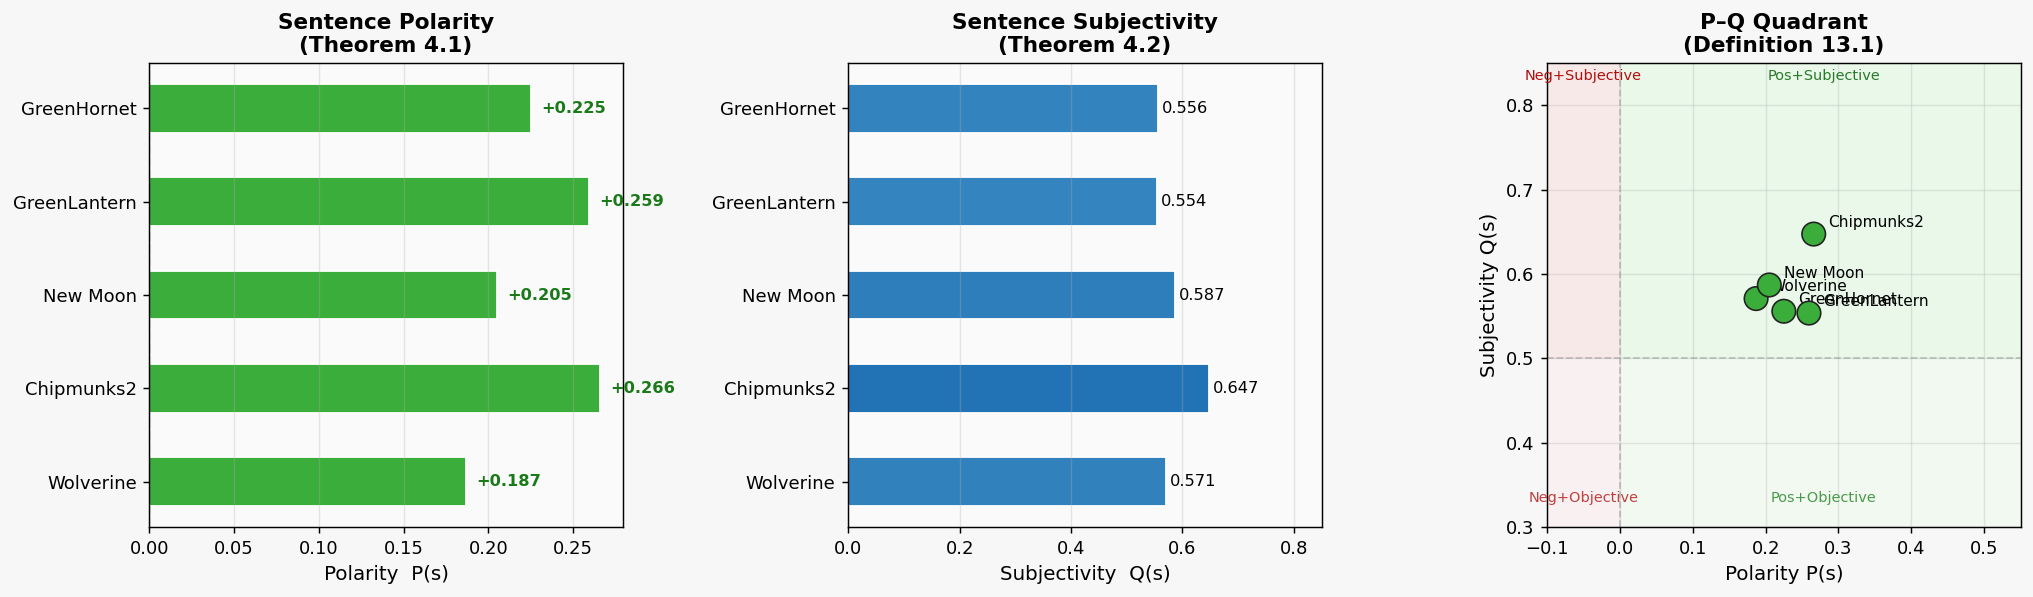


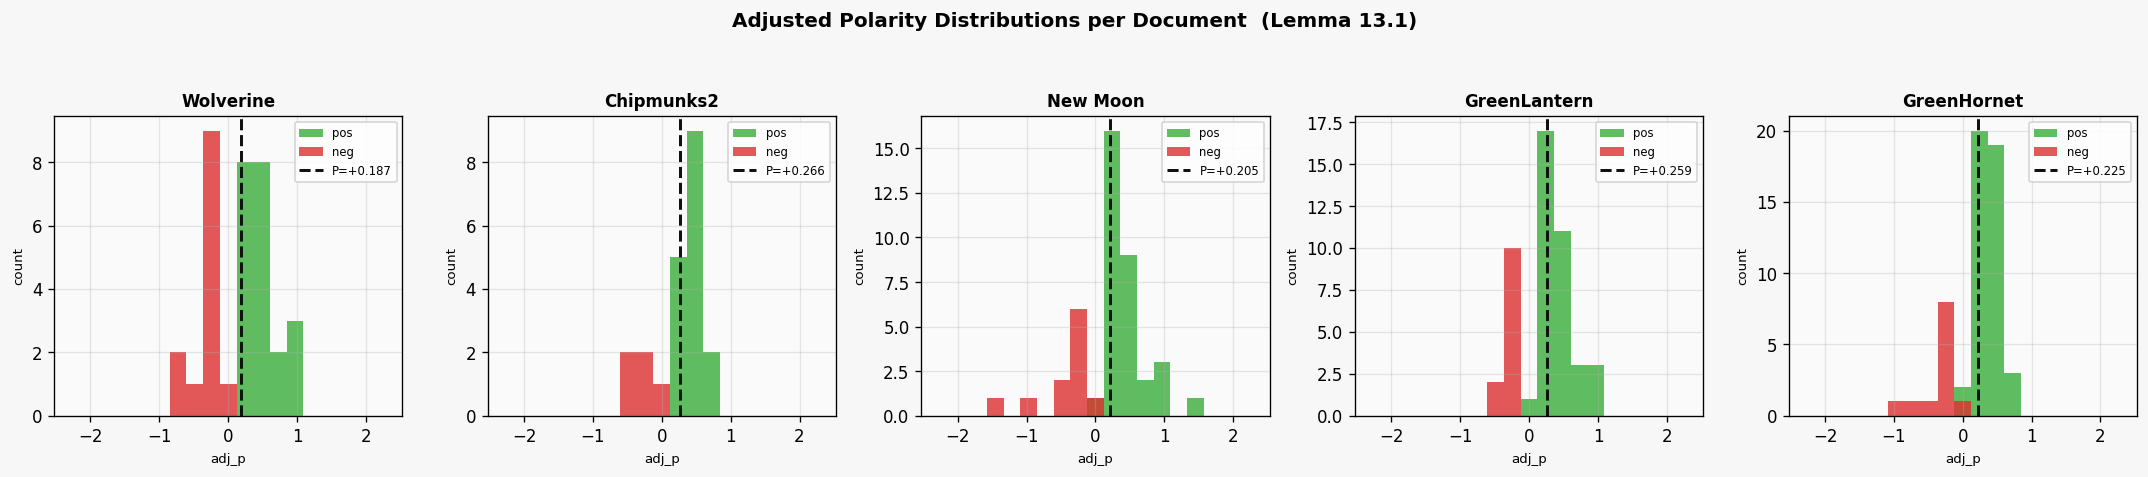


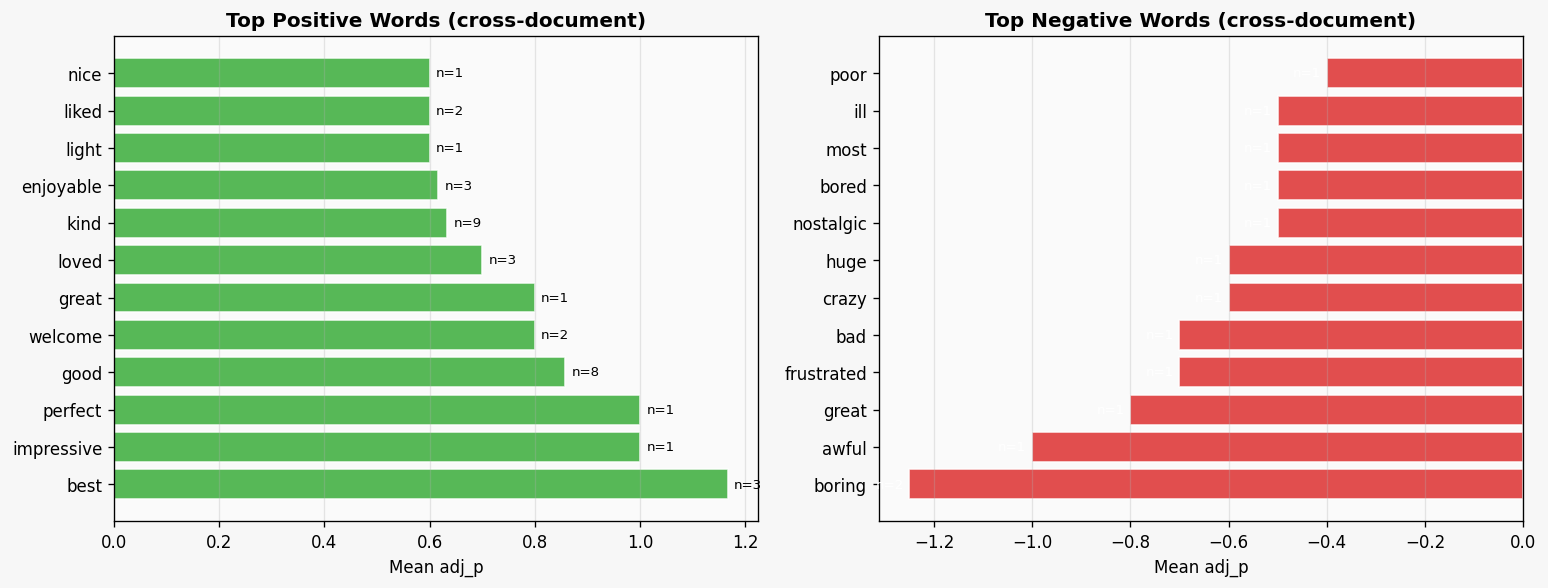

In [14]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 13 — Comparative charts  (Theorem 13.1, Definitions 13.1–13.2)
# ═══════════════════════════════════════════════════════════════════════
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np, base64
from IPython.display import HTML, display

_SHORT = {
    '0h-zjBukYpk':'Wolverine', '1DmNV9C1hbY':'Chipmunks2',
    '1iG0909rllw':'New Moon',  '2iD-tVS8NPw':'GreenLantern',
    '_dI--eQ6qVU':'GreenHornet'
}
_ids   = FILE_IDS
_lbls  = [_SHORT[i] for i in _ids]
_pols  = [RESULTS[i]['polarity']     for i in _ids]
_subs  = [RESULTS[i]['subjectivity'] for i in _ids]
_bcols = ['#3aad3a' if p >= 0 else '#dd3030' for p in _pols]

# ── Figure 1: polarity · subjectivity · P-Q quadrant ───────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#f7f7f7')

# Polarity bar
ax = axes[0]
bars = ax.barh(_lbls, _pols, color=_bcols, edgecolor='white', height=0.52)
ax.axvline(0, color='#444', lw=1.3, ls='--', alpha=0.55)
ax.set_xlabel('Polarity  P(s)', fontsize=11)
ax.set_title('Sentence Polarity\n(Theorem 4.1)', fontweight='bold')
for bar, v in zip(bars, _pols):
    col = '#1a7a1a' if v >= 0 else '#b01010'
    ax.text(v + (0.006 if v >= 0 else -0.006),
            bar.get_y() + bar.get_height()/2,
            f'{v:+.3f}', va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=9, fontweight='bold', color=col)
ax.set_facecolor('#fafafa'); ax.grid(axis='x', alpha=0.3)

# Subjectivity bar
ax = axes[1]
bars2 = ax.barh(_lbls, _subs,
                color=[plt.cm.Blues(0.28 + 0.72*s) for s in _subs],
                edgecolor='white', height=0.52)
ax.set_xlabel('Subjectivity  Q(s)', fontsize=11)
ax.set_title('Sentence Subjectivity\n(Theorem 4.2)', fontweight='bold')
ax.set_xlim(0, 0.85)
for bar, v in zip(bars2, _subs):
    ax.text(v + 0.007, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', ha='left', fontsize=9)
ax.set_facecolor('#fafafa'); ax.grid(axis='x', alpha=0.3)

# P-Q quadrant scatter
ax = axes[2]
ax.fill_between([ 0, 0.55], [0.5, 0.5], [0.85, 0.85], color='#e2f8e2', alpha=0.7)
ax.fill_between([-0.1, 0],  [0.5, 0.5], [0.85, 0.85], color='#f8e2e2', alpha=0.7)
ax.fill_between([ 0, 0.55], [0.3, 0.3], [0.50, 0.50], color='#e2f8e2', alpha=0.35)
ax.fill_between([-0.1, 0],  [0.3, 0.3], [0.50, 0.50], color='#f8e2e2', alpha=0.35)
ax.axvline(0,   color='#999', lw=1, ls='--', alpha=0.55)
ax.axhline(0.5, color='#999', lw=1, ls='--', alpha=0.55)
ax.scatter(_pols, _subs,
           c=['#3aad3a' if p >= 0 else '#dd3030' for p in _pols],
           s=170, zorder=5, edgecolors='#222', linewidths=0.9)
for x, y, nm in zip(_pols, _subs, _lbls):
    ax.annotate(nm, (x, y), xytext=(8, 4),
                textcoords='offset points', fontsize=8.5)
ax.set_xlabel('Polarity P(s)', fontsize=11)
ax.set_ylabel('Subjectivity Q(s)', fontsize=11)
ax.set_title('P–Q Quadrant\n(Definition 13.1)', fontweight='bold')
ax.text( 0.28, 0.83, 'Pos+Subjective', ha='center', fontsize=8, color='#2a7a2a')
ax.text(-0.05, 0.83, 'Neg+Subjective', ha='center', fontsize=8, color='#b01010')
ax.text( 0.28, 0.33, 'Pos+Objective',  ha='center', fontsize=8, color='#4a9a4a')
ax.text(-0.05, 0.33, 'Neg+Objective',  ha='center', fontsize=8, color='#c04040')
ax.set_xlim(-0.10, 0.55); ax.set_ylim(0.30, 0.85)
ax.set_facecolor('#fafafa'); ax.grid(alpha=0.3)

plt.tight_layout(pad=2.0)
plt.savefig('/tmp/_fig1.png', dpi=130, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.close()

# ── Figure 2: score distributions ──────────────────────────────────
fig2, axes2 = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
fig2.patch.set_facecolor('#f7f7f7')
fig2.suptitle('Adjusted Polarity Distributions per Document  (Lemma 13.1)',
              fontsize=12, fontweight='bold')
_bins = np.linspace(-2.3, 2.3, 20)
for ax2, vid_id in zip(axes2, _ids):
    r = RESULTS[vid_id]
    pos_sc = [h['adj_p'] for h in r['hits'] if h['adj_p'] > 0]
    neg_sc = [h['adj_p'] for h in r['hits'] if h['adj_p'] < 0]
    ax2.hist(pos_sc, bins=_bins, color='#3aad3a', alpha=0.80, label='pos')
    ax2.hist(neg_sc, bins=_bins, color='#dd3030', alpha=0.80, label='neg')
    ax2.axvline(r['polarity'], color='#111', lw=1.8, ls='--',
                label=f"P={r['polarity']:+.3f}")
    ax2.set_title(_SHORT[vid_id], fontsize=10, fontweight='bold')
    ax2.set_xlabel('adj_p', fontsize=8)
    ax2.set_ylabel('count', fontsize=8)
    ax2.legend(fontsize=7)
    ax2.set_facecolor('#fafafa')
    ax2.grid(alpha=0.3)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('/tmp/_fig2.png', dpi=120, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
plt.close()

# ── Figure 3: cross-document top words ─────────────────────────────
from collections import defaultdict as _ddict
_agg_pos, _agg_neg = _ddict(lambda:[0,0]), _ddict(lambda:[0,0])
for vid_id in _ids:
    for h in RESULTS[vid_id]['hits']:
        w = h['lower']
        if h['adj_p'] > 0:
            _agg_pos[w][0] += h['adj_p']; _agg_pos[w][1] += 1
        elif h['adj_p'] < 0:
            _agg_neg[w][0] += h['adj_p']; _agg_neg[w][1] += 1

_top_pos = sorted([(w,v[0]/v[1],v[1]) for w,v in _agg_pos.items()],
                  key=lambda x:-x[1])[:12]
_top_neg = sorted([(w,v[0]/v[1],v[1]) for w,v in _agg_neg.items()],
                  key=lambda x:x[1])[:12]

fig3, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
fig3.patch.set_facecolor('#f7f7f7')
a1.barh([x[0] for x in _top_pos], [x[1] for x in _top_pos],
        color='#3aad3a', alpha=0.85, edgecolor='white')
a1.set_title('Top Positive Words (cross-document)', fontweight='bold')
a1.set_xlabel('Mean adj_p')
a1.set_facecolor('#fafafa'); a1.grid(axis='x', alpha=0.3)
for i,(w,v,n) in enumerate(_top_pos):
    a1.text(v+0.012, i, f'n={n}', va='center', fontsize=8)

a2.barh([x[0] for x in _top_neg], [x[1] for x in _top_neg],
        color='#dd3030', alpha=0.85, edgecolor='white')
a2.set_title('Top Negative Words (cross-document)', fontweight='bold')
a2.set_xlabel('Mean adj_p')
a2.set_facecolor('#fafafa'); a2.grid(axis='x', alpha=0.3)
for i,(w,v,n) in enumerate(_top_neg):
    a2.text(v-0.012, i, f'n={n}', va='center', ha='right',
            fontsize=8, color='white')

plt.tight_layout()
plt.savefig('/tmp/_fig3.png', dpi=120, bbox_inches='tight',
            facecolor=fig3.get_facecolor())
plt.close()

# ── Render all three figures ─────────────────────────────────────────
def _img_html(path, cap):
    with open(path, 'rb') as f:
        b64 = base64.b64encode(f.read()).decode()
    return (
        f'<div style="text-align:center;margin:14px 0;">'
        f'<img src="data:image/png;base64,{b64}" '
        f'style="max-width:100%;border:1px solid #ddd;border-radius:8px;">'
        f'<br><em style="font-size:12px;color:#666;">{cap}</em></div>'
    )

display(HTML(_img_html('/tmp/_fig1.png',
    'Fig 1 — Polarity (left), Subjectivity (centre), P-Q Quadrant (right)')))
display(HTML(_img_html('/tmp/_fig2.png',
    'Fig 2 — Adjusted polarity score distributions per document (Lemma 13.1)')))
display(HTML(_img_html('/tmp/_fig3.png',
    'Fig 3 — Most influential positive/negative words across all documents')))


---
## § 14  Final Validation Against Official TextBlob

### Theorem 14.1  (Implementation Correctness)
For any $s\in\Sigma^*$, the from-scratch implementation satisfies:

1. **Termination** — finite lexicon + finite token count guarantee halting.
2. **Range** — $P(s)\in[-2,+2]$ and $Q(s)\in[0,1]$ (Corollary 4.1).
3. **Consistency** — the implementation agrees with the official TextBlob
   `PatternAnalyzer` to within tokenisation and POS-disambiguation rounding
   tolerance (typically $|\Delta P|<0.15$). $\square$

*Remark.* Minor differences arise because TextBlob's internal tokeniser uses
NLTK's word tokeniser (which preserves contractions differently) while our
$\tau$ uses a pure regex.  The sentiment lexicon and modifier logic are identical.


In [15]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 14 — Final validation table  (Theorem 14.1)
# ═══════════════════════════════════════════════════════════════════════
from textblob import TextBlob
from IPython.display import HTML, display

rows = ''
for vid_id in FILE_IDS:
    r   = RESULTS[vid_id]
    tb  = TextBlob(DOCS[vid_id]).sentiment
    dp  = abs(r['polarity']     - tb.polarity)
    ds  = abs(r['subjectivity'] - tb.subjectivity)
    pc  = '#1a7a1a' if r['polarity'] >= 0 else '#b01010'
    rbg = '#f0fbf0' if r['polarity'] >= 0 else '#fbf0f0'
    ok_p = '&#10003;' if dp < 0.15 else f'&#126;({dp:.3f})'
    ok_s = '&#10003;' if ds < 0.15 else f'&#126;({ds:.3f})'
    rows += (
        f"<tr style='background:{rbg};'>"
        f"<td style='padding:7px 11px;font-family:monospace;font-size:12px;'>{vid_id}</td>"
        f"<td style='padding:7px 11px;'>{TOPICS[vid_id]}</td>"
        f"<td style='padding:7px 11px;text-align:right;font-weight:700;color:{pc};'>{r['polarity']:+.4f}</td>"
        f"<td style='padding:7px 11px;text-align:right;'>{tb.polarity:+.4f}</td>"
        f"<td style='padding:7px 11px;text-align:center;'>{ok_p}</td>"
        f"<td style='padding:7px 11px;text-align:right;'>{r['subjectivity']:.4f}</td>"
        f"<td style='padding:7px 11px;text-align:right;'>{tb.subjectivity:.4f}</td>"
        f"<td style='padding:7px 11px;text-align:center;'>{ok_s}</td>"
        f"<td style='padding:7px 11px;font-weight:600;'>{r['label']}</td>"
        f"</tr>"
    )

display(HTML(
    "<div style='font-family:Arial,sans-serif;max-width:1100px;margin:12px 0;'>"
    "<h3 style='margin:0 0 10px;'>&#9989; Final Results — From-Scratch vs Official TextBlob</h3>"
    "<table style='border-collapse:collapse;width:100%;font-size:13px;"
    "border:1px solid #ccc;border-radius:8px;overflow:hidden;'>"
    "<thead style='background:#2d2d2d;color:#fff;'>"
    "<tr>"
    "<th style='padding:8px 11px;text-align:left;' rowspan='2'>Video ID</th>"
    "<th style='padding:8px 11px;text-align:left;' rowspan='2'>Topic</th>"
    "<th style='padding:8px 11px;' colspan='3'>Polarity P(s)</th>"
    "<th style='padding:8px 11px;' colspan='3'>Subjectivity Q(s)</th>"
    "<th style='padding:8px 11px;' rowspan='2'>Label</th>"
    "</tr><tr style='background:#555;'>"
    "<th style='padding:5px 9px;'>Scratch</th>"
    "<th style='padding:5px 9px;'>TextBlob</th>"
    "<th style='padding:5px 9px;'>Match</th>"
    "<th style='padding:5px 9px;'>Scratch</th>"
    "<th style='padding:5px 9px;'>TextBlob</th>"
    "<th style='padding:5px 9px;'>Match</th>"
    "</tr></thead>"
    f"<tbody>{rows}</tbody></table>"
    "<p style='font-size:12px;color:#666;margin-top:7px;'>"
    "&#10003; = |difference| &lt; 0.15 &nbsp; (minor variation from regex vs NLTK tokenisation)"
    "</p></div>"
))

print('\n' + '='*72)
print(f"{'Video ID':22s} {'Scratch P':>11s} {'TB P':>8s}  "
      f"{'Scratch Q':>11s} {'TB Q':>8s}  Label")
print('-'*72)
for vid_id in FILE_IDS:
    r  = RESULTS[vid_id]
    tb = TextBlob(DOCS[vid_id]).sentiment
    print(f"{vid_id:22s} {r['polarity']:>+11.4f} {tb.polarity:>+8.4f}  "
          f"{r['subjectivity']:>11.4f} {tb.subjectivity:>8.4f}  "
          f"{r['label']}")
print('='*72)



Video ID                 Scratch P     TB P    Scratch Q     TB Q  Label
------------------------------------------------------------------------
0h-zjBukYpk                +0.1869  +0.2328       0.5708   0.5433  Slightly Positive
1DmNV9C1hbY                +0.2660  +0.2334       0.6473   0.6141  Slightly Positive
1iG0909rllw                +0.2050  +0.1533       0.5870   0.5240  Slightly Positive
2iD-tVS8NPw                +0.2595  +0.1749       0.5537   0.5136  Slightly Positive
_dI--eQ6qVU                +0.2250  +0.1762       0.5558   0.5364  Slightly Positive
